In [2]:
# RRCP (07/08/2026): K-Means para Jugadores
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import ipywidgets as widgets

In [3]:
# Cargamos los datos
df_jugadores = pd.read_csv("../data/jugadores_cebollitas.csv")
df_jugadores.head()

,jugador_id,nombre,posición,edad,partidos_jugados,goles,asistencias,pases_completados (%),tiros_al_arco,precisión_tiros (%),minutos_jugados
0,1,Tara Alvarez,Portero,18,25,2,5,89.0,8,78.2,2125
1,2,Carol Mcclain,Mediocampista,32,12,2,8,77.5,49,68.5,1032
2,3,Robert Martin,Defensa,26,12,4,5,87.3,1,71.4,816
3,4,Mr. Robert Turner,Defensa,25,17,2,4,75.9,9,35.8,1496
4,5,Christopher Kennedy,Defensa,35,23,1,7,83.5,0,0.0,2047


In [4]:
df_jugadores.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   jugador_id             20 non-null     int64  
 1   nombre                 20 non-null     str    
 2   posición               20 non-null     str    
 3   edad                   20 non-null     int64  
 4   partidos_jugados       20 non-null     int64  
 5   goles                  20 non-null     int64  
 6   asistencias            20 non-null     int64  
 7   pases_completados (%)  20 non-null     float64
 8   tiros_al_arco          20 non-null     int64  
 9   precisión_tiros (%)    20 non-null     float64
 10  minutos_jugados        20 non-null     int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 1.8 KB


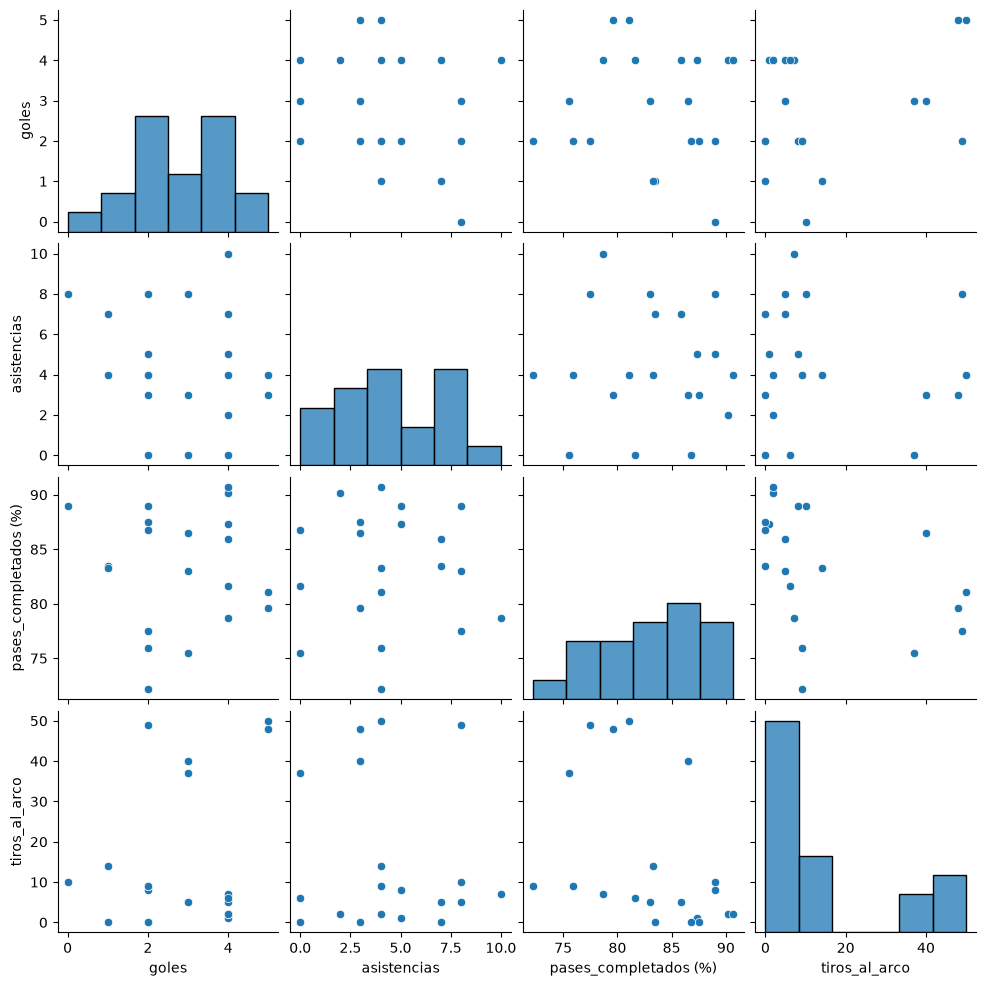

In [5]:
# Matriz gráfica que permite observar visualmente las relaciones entre las variables numéricas.
# Con 4 variables tendrás una matriz de 4 × 4 = 16 gráficos.
"""
                      goles     asistencias    pases (%)    tiros_al_arco
                    ┌──────────┬──────────────┬────────────┬───────────────┐
goles               │ histograma│ relación    │ relación   │ relación      │
                    ├──────────┼──────────────┼────────────┼───────────────┤
asistencias         │ relación │ histograma   │ relación   │ relación      │
                    ├──────────┼──────────────┼────────────┼───────────────┤
pases (%)           │ relación │ relación     │ histograma │ relación      │
                    ├──────────┼──────────────┼────────────┼───────────────┤
tiros_al_arco       │ relación │ relación     │ relación   │ histograma    │
                    └──────────┴──────────────┴────────────┴───────────────┘
"""
sns.pairplot(
    df_jugadores[
        ['goles', 'asistencias', 'pases_completados (%)', 'tiros_al_arco']
    ]
)

plt.show()

In [6]:
X = df_jugadores[
    ['goles', 'asistencias', 'pases_completados (%)', 'tiros_al_arco']
]

kmeans = KMeans(n_clusters = 3, random_state = 42) # Instancia de KMeans con 3 clusters.
df_jugadores['cluster'] = kmeans.fit_predict(X) # Asigna centroides al azar y asigna jugadores.

df_jugadores.head()

,jugador_id,nombre,posición,edad,partidos_jugados,goles,asistencias,pases_completados (%),tiros_al_arco,precisión_tiros (%),minutos_jugados,cluster
0,1,Tara Alvarez,Portero,18,25,2,5,89.0,8,78.2,2125,1
1,2,Carol Mcclain,Mediocampista,32,12,2,8,77.5,49,68.5,1032,0
2,3,Robert Martin,Defensa,26,12,4,5,87.3,1,71.4,816,1
3,4,Mr. Robert Turner,Defensa,25,17,2,4,75.9,9,35.8,1496,2
4,5,Christopher Kennedy,Defensa,35,23,1,7,83.5,0,0.0,2047,1


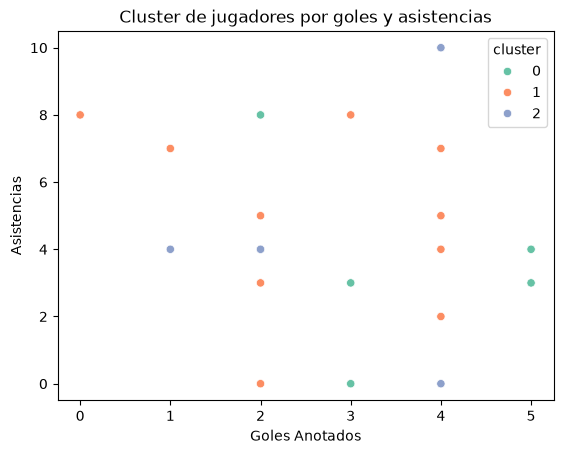

In [7]:
sns.scatterplot(x = 'goles', y = 'asistencias', hue = 'cluster', palette = 'Set2' , data = df_jugadores)
plt.title("Cluster de jugadores por goles y asistencias")
plt.xlabel("Goles Anotados")
plt.ylabel("Asistencias")
plt.show()

In [8]:
columnas_numericas = ['goles', 'asistencias', 'pases_completados (%)', 'tiros_al_arco']
perfiles = df_jugadores.groupby('cluster')[columnas_numericas].mean() # Calcula el perfil medio de cada grupo.
print(perfiles)

         goles  asistencias  pases_completados (%)  tiros_al_arco
cluster                                                          
0          3.6          3.6                  80.04           44.8
1          2.6          4.9                  87.29            3.3
2          2.6          4.4                  78.34            9.0


In [9]:
def clustering_interactivo(k):
    km = KMeans(n_clusters = k, random_state = 42)
    df_jugadores['cluster_temp'] = km.fit_predict(X)

    sns.scatterplot(x = 'goles', y = 'asistencias', hue = 'cluster_temp', palette = 'Set1', data = df_jugadores)
    plt.title(f"Clustering jugadores con {k} clusters")
    plt.xlabel("Goles")
    plt.ylabel("Asistencias")
    plt.show()

widgets.interactive(clustering_interactivo, k = (2,6,1))

interactive(children=(IntSlider(value=4, description='k', max=6, min=2), Output()), _dom_classes=('widget-inte…